<a href="https://colab.research.google.com/github/Gayathri-achari/Projects/blob/road_accidents/Road_Accidents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from datetime import datetime

sns.set(style="whitegrid", context="talk")

In [2]:
df = pd.read_csv("/content/cleaned_road_data (1).csv")

In [3]:
print("✅ Dataset Loaded")

✅ Dataset Loaded


In [4]:
print("Shape:", df.shape)

Shape: (307972, 22)


In [5]:
print("\nColumns:", df.columns.tolist())


Columns: ['Accident_Index', 'Accident Date', 'Month', 'Day_of_Week', 'Year', 'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type']


In [6]:
print("\n--- Missing Values Summary ---")
print(df.isna().sum())


--- Missing Values Summary ---
Accident_Index                0
Accident Date                 0
Month                         0
Day_of_Week                   0
Year                          0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64


In [7]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
Accident_Index                 object
Accident Date                  object
Month                          object
Day_of_Week                    object
Year                            int64
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object


In [8]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')

In [9]:
df['Accident_Year'] = df['Accident Date'].dt.year
df['Accident_Month'] = df['Accident Date'].dt.month_name()
df['Accident_Day'] = df['Accident Date'].dt.day
df['Weekday'] = df['Accident Date'].dt.day_name()

In [10]:
def extract_hour(time_str):
    try:
        t = datetime.strptime(time_str, "%H:%M")
        return t.hour
    except:
        return np.nan

df['Hour'] = df['Time'].apply(extract_hour)

In [11]:
print("\n--- Basic Summary ---")
print(df.describe(include='all').T)



--- Basic Summary ---
                               count  unique  \
Accident_Index                307972  197644   
Accident Date                 307972     NaN   
Month                         307972      12   
Day_of_Week                   307972       7   
Year                        307972.0     NaN   
Junction_Control              307972       6   
Junction_Detail               307972       9   
Accident_Severity             307972       3   
Latitude                    307972.0     NaN   
Light_Conditions              307972       5   
Local_Authority_(District)    307972     422   
Longitude                   307972.0     NaN   
Number_of_Casualties        307972.0     NaN   
Number_of_Vehicles          307972.0     NaN   
Police_Force                  307972      51   
Road_Surface_Conditions       307972       5   
Road_Type                     307972       5   
Speed_limit                 307972.0     NaN   
Time                          307972    1439   
Urban_or_Rural_Ar

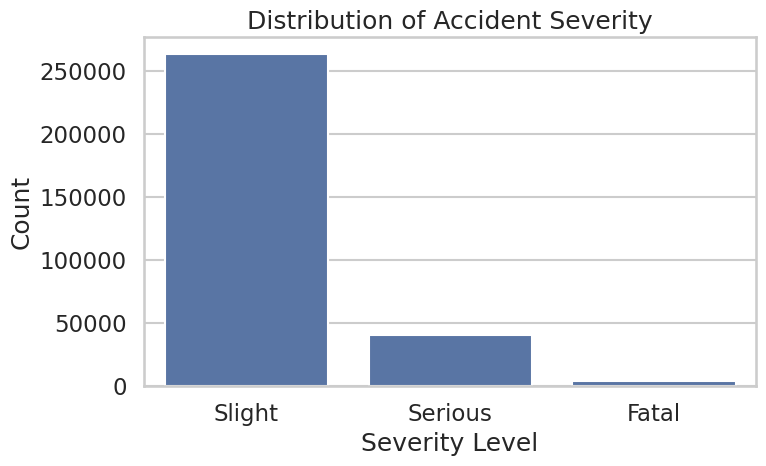

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Accident_Severity', order=df['Accident_Severity'].value_counts().index)
plt.title("Distribution of Accident Severity")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


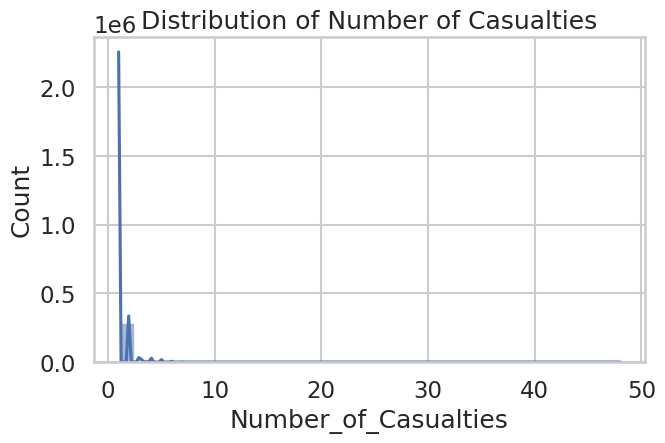

In [13]:
plt.figure(figsize=(7,5))
sns.histplot(df['Number_of_Casualties'], bins=30, kde=True)
plt.title("Distribution of Number of Casualties")
plt.tight_layout()
plt.show()


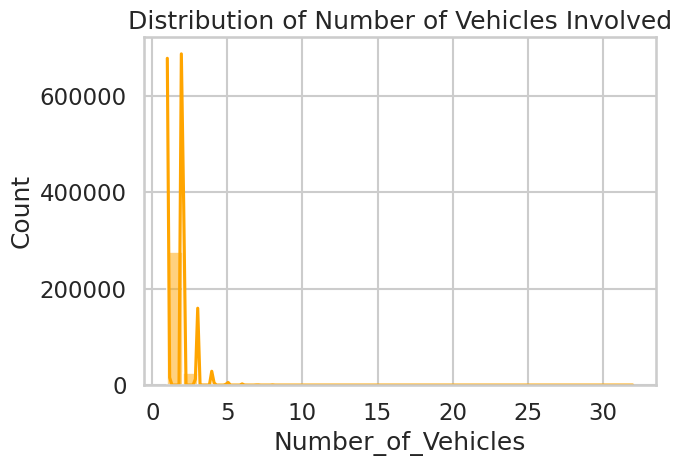

In [14]:
plt.figure(figsize=(7,5))
sns.histplot(df['Number_of_Vehicles'], bins=30, kde=True, color='orange')
plt.title("Distribution of Number of Vehicles Involved")
plt.tight_layout()
plt.show()

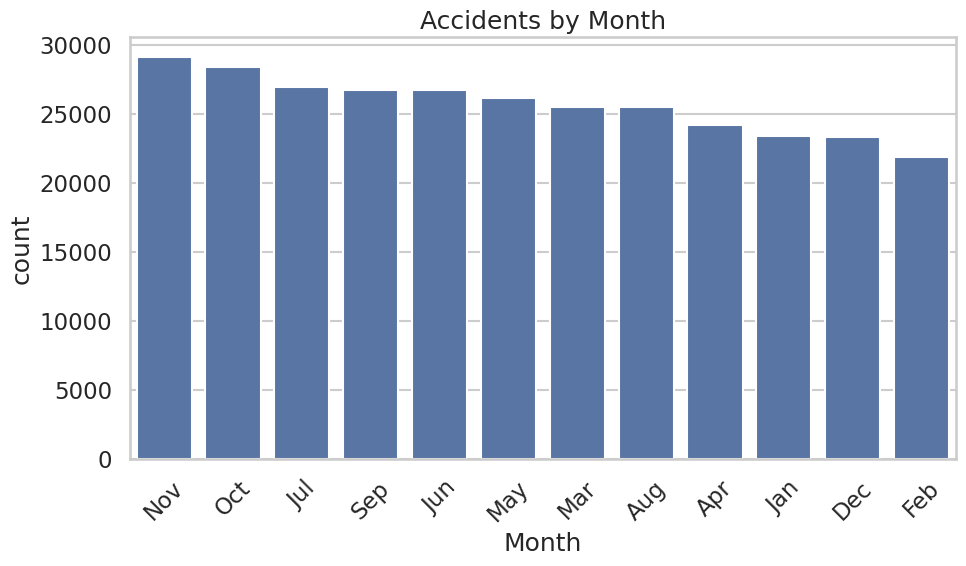

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Month', order=df['Month'].value_counts().index)
plt.title("Accidents by Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

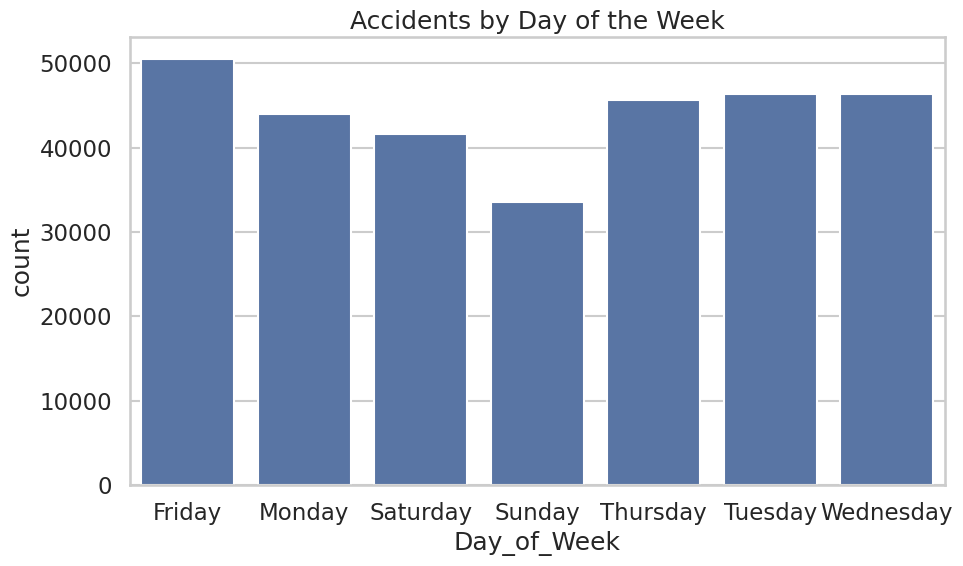

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Day_of_Week', order=sorted(df['Day_of_Week'].unique()))
plt.title("Accidents by Day of the Week")
plt.tight_layout()
plt.show()


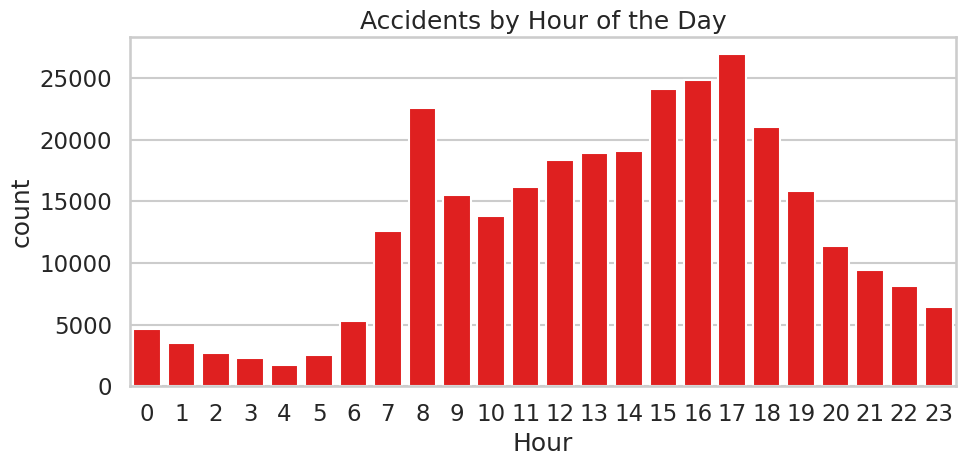

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Hour', color='red')
plt.title("Accidents by Hour of the Day")
plt.tight_layout()
plt.show()

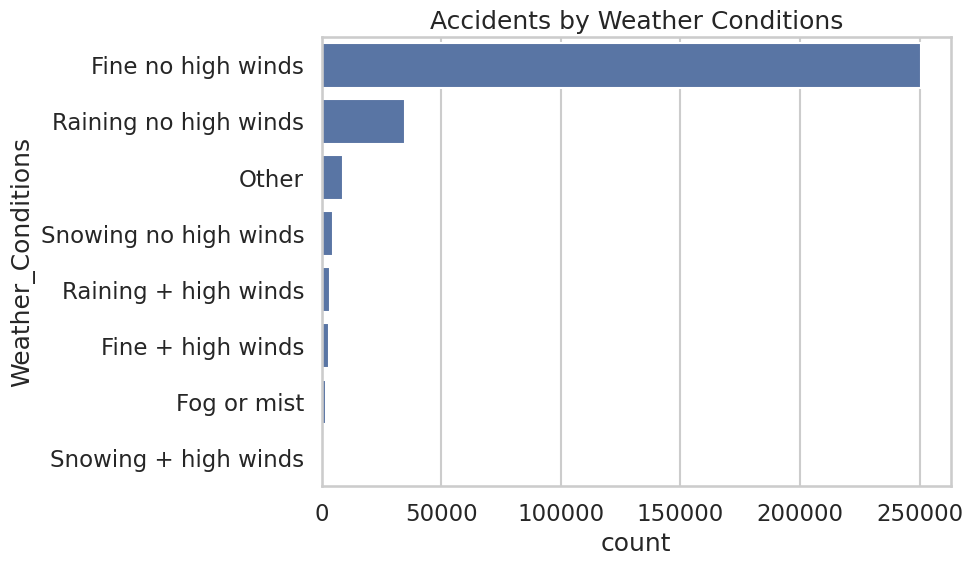

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', data=df, order=df['Weather_Conditions'].value_counts().index)
plt.title("Accidents by Weather Conditions")
plt.tight_layout()
plt.show()


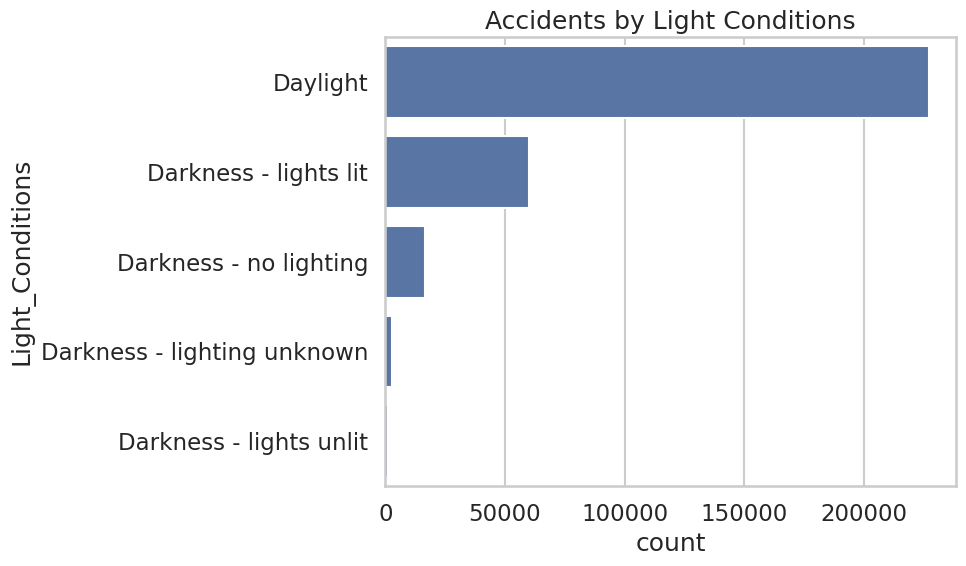

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(y='Light_Conditions', data=df, order=df['Light_Conditions'].value_counts().index)
plt.title("Accidents by Light Conditions")
plt.tight_layout()
plt.show()

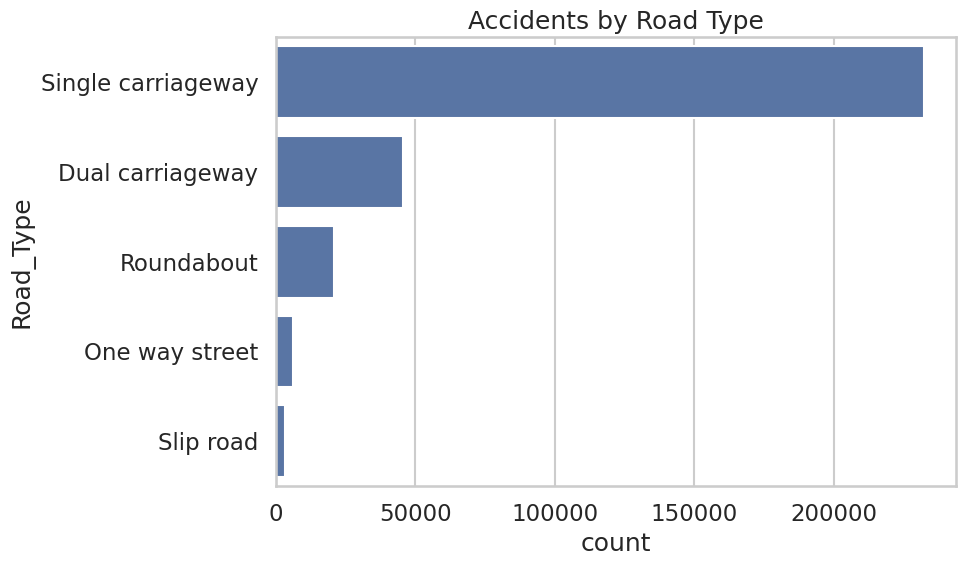

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(y='Road_Type', data=df, order=df['Road_Type'].value_counts().index)
plt.title("Accidents by Road Type")
plt.tight_layout()
plt.show()

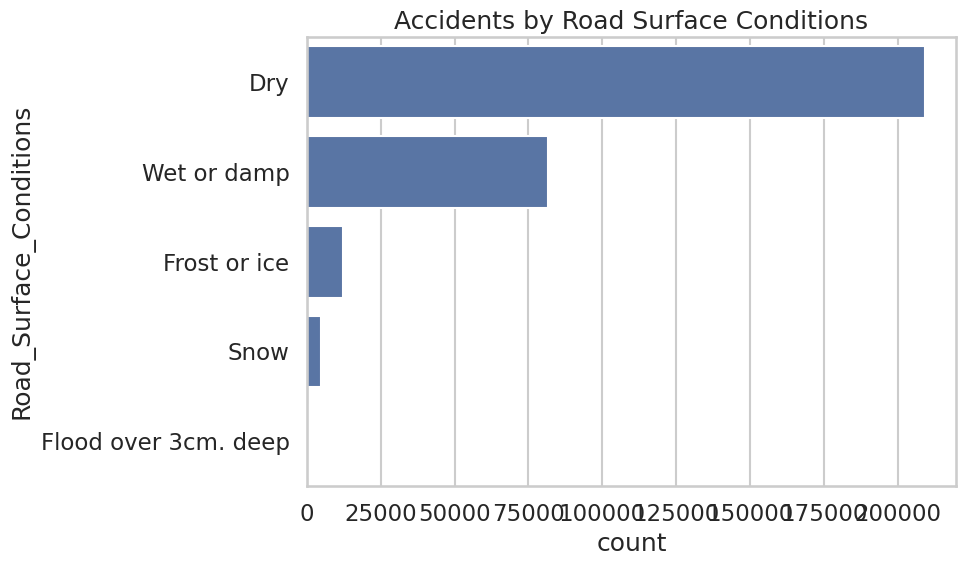

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(y='Road_Surface_Conditions', data=df, order=df['Road_Surface_Conditions'].value_counts().index)
plt.title("Accidents by Road Surface Conditions")
plt.tight_layout()
plt.show()

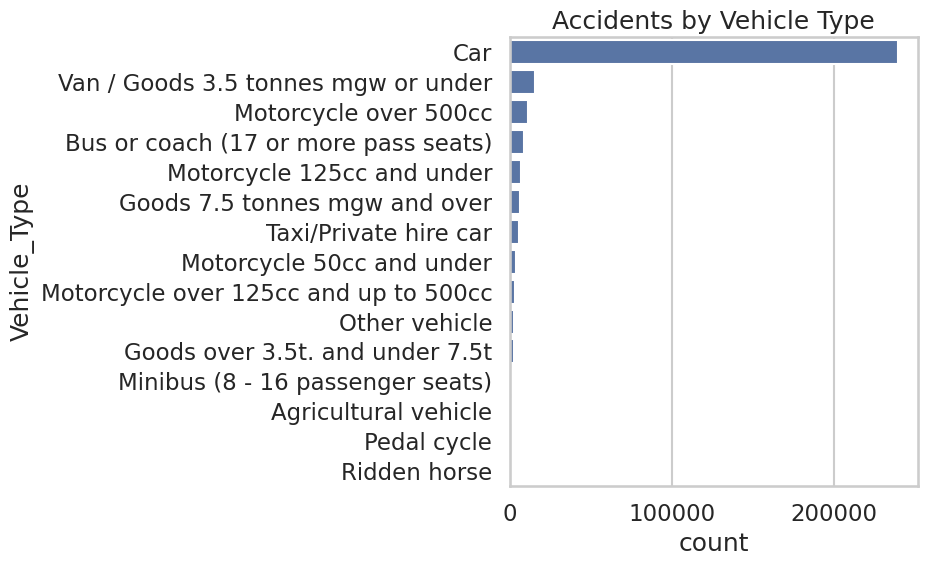

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(y='Vehicle_Type', data=df, order=df['Vehicle_Type'].value_counts().index)
plt.title("Accidents by Vehicle Type")
plt.tight_layout()
plt.show()


In [23]:
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=6, tiles='CartoDB positron')

heat_data = df[['Latitude', 'Longitude']].values.tolist()
HeatMap(heat_data, radius=7, blur=15).add_to(m)

m.save("road_accident_heatmap.html")
print("🗺️ Heatmap saved as 'road_accident_heatmap.html' — open it in your browser.")

🗺️ Heatmap saved as 'road_accident_heatmap.html' — open it in your browser.


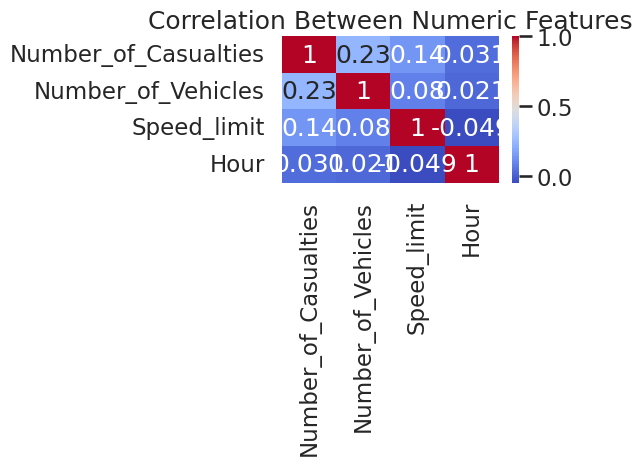

In [24]:
num_cols = ['Number_of_Casualties', 'Number_of_Vehicles', 'Speed_limit', 'Hour']
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()


In [25]:
summary = {
    'Total Accidents': len(df),
    'Years Covered': df['Year'].nunique(),
    'Average Casualties per Accident': round(df['Number_of_Casualties'].mean(), 2),
    'Most Common Weather Condition': df['Weather_Conditions'].mode()[0],
    'Most Common Road Type': df['Road_Type'].mode()[0],
    'Most Common Light Condition': df['Light_Conditions'].mode()[0],
}
print("\n📊 Summary Report:")
for k, v in summary.items():
    print(f"{k}: {v}")

print("\n✅ EDA Completed Successfully!")


📊 Summary Report:
Total Accidents: 307972
Years Covered: 2
Average Casualties per Accident: 1.36
Most Common Weather Condition: Fine no high winds
Most Common Road Type: Single carriageway
Most Common Light Condition: Daylight

✅ EDA Completed Successfully!


Hotspot detection (DBSCAN) — cluster accident locations and save map


In [26]:
# hotspot_dbscan.py
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import folium
from folium.plugins import MarkerCluster, HeatMap

# Load
df = pd.read_csv("/content/cleaned_road_data (1).csv", parse_dates=["Accident Date"], dayfirst=True)
df = df.dropna(subset=['Latitude', 'Longitude']).copy()
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df = df.dropna(subset=['Latitude','Longitude'])

# Prepare coords (DBSCAN on projected coordinates approximated by lat/lon -> convert deg to rad and use haversine option OR scale in degrees for small regions)
coords = df[['Latitude','Longitude']].values

# If clustering across large geographic area, convert to radians and use haversine metric:
kms_per_radian = 6371.0088
# eps = 0.5 km for cluster radius example -> convert to radians
eps_km = 0.5
eps = eps_km / kms_per_radian

# convert to radians
coords_radians = np.radians(coords)

db = DBSCAN(eps=eps, min_samples=10, metric='haversine', n_jobs=-1)
db.fit(coords_radians)
labels = db.labels_
df['cluster'] = labels

# Summary
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Clusters found: {n_clusters}")
print("Noise points:", (labels == -1).sum())

# Cluster sizes
cluster_sizes = df[df['cluster']!=-1].groupby('cluster').size().sort_values(ascending=False)
print(cluster_sizes.head(10))

# Build folium map with clusters
center = [df['Latitude'].median(), df['Longitude'].median()]
m = folium.Map(location=center, zoom_start=6, tiles='CartoDB positron')

# Color map for clusters
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
palette = plt.cm.get_cmap('tab20', max(1, n_clusters+1))

marker_cluster = MarkerCluster().add_to(m)

for i, row in df.iterrows():
    lbl = row['cluster']
    if lbl == -1:
        color = 'grey'
    else:
        rgba = palette(lbl % 20)
        color = mcolors.to_hex(rgba)
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"Index: {row['Accident_Index']}<br>Cluster:{lbl}<br>Severity:{row.get('Accident_Severity','')}"
    ).add_to(marker_cluster)

# Save map
m.save("hotspots_dbscan_map.html")
print("Saved hotspots map to hotspots_dbscan_map.html")

# Optionally output cluster centers and recommended actions
cluster_centers = df[df['cluster']!=-1].groupby('cluster')[['Latitude','Longitude']].median().reset_index()
cluster_centers['count'] = df[df['cluster']!=-1].groupby('cluster').size().values
cluster_centers = cluster_centers.sort_values('count', ascending=False)
cluster_centers.to_csv("cluster_centers.csv", index=False)
print("Saved cluster_centers.csv with coordinates and counts.")


Clusters found: 2406
Noise points: 96944
cluster
0       48494
695      9420
186      5272
465      4872
325      2864
150      2827
1870     2537
964      2409
1033     2375
616      2247
dtype: int64
Saved hotspots map to hotspots_dbscan_map.html
Saved cluster_centers.csv with coordinates and counts.


Rule-based Infrastructure Recommendation Engine

In [28]:
# infra_recommendations.py
import pandas as pd
import numpy as np

df = pd.read_csv("/content/cleaned_road_data (1).csv", parse_dates=["Accident Date"], dayfirst=True)
df = df.dropna(subset=['Latitude','Longitude'])
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour.fillna(-1).astype(int)
df['is_night'] = df['Hour'].apply(lambda h: 1 if (h>=20 or h<=5) else 0)

# Suppose we have cluster_centers.csv produced earlier
# If not present, compute top coordinates by rounding:
df['lat_r'] = df['Latitude'].round(3)
df['lon_r'] = df['Longitude'].round(3)
hot = df.groupby(['lat_r','lon_r']).agg(
    total_accidents = ('Accident_Index','count'),
    fatal_or_serious = ('Accident_Severity', lambda s: (s.isin(['3','2']) | s.str.contains('Fatal|Serious', case=False, na=False)).sum()),
    night_accidents = ('is_night','sum'),
    avg_speed_limit = ('Speed_limit', lambda x: pd.to_numeric(x, errors='coerce').mean())
).reset_index().sort_values('total_accidents', ascending=False).head(100)

def recommend(row):
    recs = []
    if row['total_accidents'] >= 10:
        recs.append("Investigate hotspot - consider engineering solutions")
    if row['fatal_or_serious'] / max(1,row['total_accidents']) > 0.2:
        recs.append("Priority: Install speed reduction measures & signage")
    if row['night_accidents'] / max(1,row['total_accidents']) > 0.3:
        recs.append("Improve street lighting & reflective signage")
    if row['avg_speed_limit'] and row['avg_speed_limit'] >= 50:
        recs.append("Assess lowering speed limit or add traffic calming")
    if not recs:
        recs.append("Monitor and collect more data")
    return "; ".join(recs)

hot['recommendations'] = hot.apply(recommend, axis=1)
hot[['lat_r','lon_r','total_accidents','fatal_or_serious','night_accidents','avg_speed_limit','recommendations']].to_csv("hotspot_recommendations.csv", index=False)
print("Saved hotspot_recommendations.csv with recommended interventions.")


Saved hotspot_recommendations.csv with recommended interventions.


Smart Navigation — geofencing & API-ready geojson for warnings

In [57]:
# geofence_hotspots.py
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
import json

# Load cluster centers from earlier clustering step or compute simple top N hotspots
df = pd.read_csv("/content/cleaned_road_data (1).csv", parse_dates=["Accident Date"], dayfirst=True)
df = df.dropna(subset=['Latitude','Longitude'])
# Quick grid hotspot: group by rounded coordinates
df['lat_r'] = df['Latitude'].round(3)
df['lon_r'] = df['Longitude'].round(3)
hot = df.groupby(['lat_r','lon_r']).size().reset_index(name='count').sort_values('count', ascending=False).head(50)
hot['center_lat'] = hot['lat_r']
hot['center_lon'] = hot['lon_r']

# Build circular geofence polygons (approximate as square buffer in degrees)
def square_buffer(lat, lon, radius_deg=0.01):
    # square buffer for simplicity
    return Polygon([
        (lon-radius_deg, lat-radius_deg),
        (lon-radius_deg, lat+radius_deg),
        (lon+radius_deg, lat+radius_deg),
        (lon+radius_deg, lat-radius_deg)
    ])

geofences = []
for idx, row in hot.iterrows():
    poly = square_buffer(row['center_lat'], row['center_lon'], radius_deg=0.01)
    geofences.append({
        "id": int(idx),
        "count": int(row['count']),
        "center": [row['center_lat'], row['center_lon']],
        "geometry": json.loads(json.dumps(poly.__geo_interface__))
    })

# Save as GeoJSON FeatureCollection
features = []
for g in geofences:
    features.append({
        "type":"Feature",
        "properties":{"id":g['id'], "count": g['count']},
        "geometry": g['geometry']
    })

geojson = {"type":"FeatureCollection","features":features}
with open("hotspot_geofences.geojson","w") as f:
    json.dump(geojson, f)
print("Saved hotspot_geofences.geojson")

# Function to test if a point is inside any hotspot
from shapely.geometry import shape

polygons = [(feat['properties']['id'], shape(feat['geometry'])) for feat in geojson['features']]

def is_in_hotspot(lat, lon):
    pt = Point(lon, lat)
    hit = []
    for pid, poly in polygons:
        if poly.contains(pt):
            hit.append(pid)
    return hit

# Example
print(is_in_hotspot(51.5074, -0.1278))


Saved hotspot_geofences.geojson
[56185, 58400, 57976, 57189, 57344]


In [69]:
import json
with open('/content/hotspot_geofences.geojson', 'r') as f:
  geojson_data = json.load(f)
  print(geojson_data)

{'type': 'FeatureCollection', 'features': [{'type': 'Feature', 'properties': {'id': 71208, 'count': 36}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-0.21000000000000002, 51.580000000000005], [-0.21000000000000002, 51.6], [-0.19, 51.6], [-0.19, 51.580000000000005], [-0.21000000000000002, 51.580000000000005]]]}}, {'type': 'Feature', 'properties': {'id': 68386, 'count': 33}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-0.106, 51.561], [-0.106, 51.580999999999996], [-0.08600000000000001, 51.580999999999996], [-0.08600000000000001, 51.561], [-0.106, 51.561]]]}}, {'type': 'Feature', 'properties': {'id': 60794, 'count': 30}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-0.045000000000000005, 51.515], [-0.045000000000000005, 51.535], [-0.025, 51.535], [-0.025, 51.515], [-0.045000000000000005, 51.515]]]}}, {'type': 'Feature', 'properties': {'id': 55185, 'count': 29}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-0.111, 51.485], [-0.111, 51.504999999999995], [-0.0910000000

Severity model

In [34]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.9 MB/s eta 0:00:00


In [40]:
# severity_prediction.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

# Load
df = pd.read_csv("/content/cleaned_road_data (1).csv", parse_dates=["Accident Date"], dayfirst=True)

# Basic cleaning
df = df.dropna(subset=['Accident_Severity']).copy()
# Convert target to string (in case it's numeric codes)
df['Accident_Severity'] = df['Accident_Severity'].astype(str)

# Feature engineering
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
df['Month'] = pd.to_datetime(df['Accident Date'], errors='coerce').dt.month
df['Is_Junction'] = df['Junction_Detail'].fillna('').str.contains('junction|roundabout', case=False, na=False).astype(int)

# Choose features — adapt as needed
features = [
    'Hour','Month','Number_of_Casualties','Number_of_Vehicles','Speed_limit',
    'Light_Conditions','Road_Surface_Conditions','Road_Type','Weather_Conditions','Vehicle_Type','Urban_or_Rural_Area'
]
# Keep only rows with non-null in selected features or fill na
df = df.copy()
for col in features:
    if col not in df.columns:
        df[col] = np.nan

df[features] = df[features].fillna('Unknown')  # simple treatment; numeric columns are strings too => will need conversion

# Distinguish numeric vs categorical
numeric_features = ['Hour','Number_of_Casualties','Number_of_Vehicles','Speed_limit','Month']
categorical_features = [c for c in features if c not in numeric_features]

# Convert numeric cols properly
for c in numeric_features:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

X = df[features]
y = df['Accident_Severity']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Preprocessing & pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Classification report:")
print(classification_report(y_test, y_pred))

# Feature importance (approx)
# Get feature names from preprocessor
ohe = pipeline.named_steps['prep'].named_transformers_['cat']
ohe_cols = list(ohe.get_feature_names_out(categorical_features))
final_feature_names = numeric_features + ohe_cols
importances = pipeline.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': final_feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(40)
print(imp_df)

# Save model
joblib.dump(pipeline, "severity_rf_pipeline.joblib")
print("Saved model to severity_rf_pipeline.joblib")

Classification report:
              precision    recall  f1-score   support

       Fatal       0.02      0.00      0.00       791
     Serious       0.21      0.05      0.08      8148
      Slight       0.86      0.97      0.91     52656

    accuracy                           0.84     61595
   macro avg       0.36      0.34      0.33     61595
weighted avg       0.76      0.84      0.79     61595

                                              feature  importance
0                                                Hour    0.323278
4                                               Month    0.262835
2                                  Number_of_Vehicles    0.078054
1                                Number_of_Casualties    0.072671
3                                         Speed_limit    0.062675
30                                   Vehicle_Type_Car    0.015881
42   Vehicle_Type_Van / Goods 3.5 tonnes mgw or under    0.010616
14                Road_Surface_Conditions_Wet or damp    0.008749
37

In [58]:
    pip install joblib

In [70]:
import joblib
loaded_object = joblib.load('/content/severity_rf_pipeline.joblib')
loaded_object

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Hour',
                                                   'Number_of_Casualties',
                                                   'Number_of_Vehicles',
                                                   'Speed_limit', 'Month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Light_Conditions',
                                                   'Road_Surface_Conditions',
                                                   'Road_Type',
                                                   'Weather_Conditions',
                                                   'Vehicle_Type',
                                                   'Urban_or_Rural_Area'])])),
                ('clf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

Forecasting

In [62]:
# weather_alerts.py
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import joblib
import requests
from datetime import datetime

# Load dataset and train a small classifier (re-using earlier pipeline is better)
df = pd.read_csv("/content/cleaned_road_data (1).csv", parse_dates=["Accident Date"], dayfirst=True)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour.fillna(0).astype(int)
df['Month'] = pd.to_datetime(df['Accident Date'], errors='coerce').dt.month.fillna(0).astype(int)
df = df.dropna(subset=['Accident_Severity'])
df['Accident_Severity'] = df['Accident_Severity'].astype(str)

# Simple feature subset
X = df[['Hour','Month','Number_of_Casualties','Number_of_Vehicles','Speed_limit']].fillna(0)
y = df['Accident_Severity']
clf = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1)
clf.fit(X, y)
joblib.dump(clf, "weather_alerts_rf.joblib")

# Example function: get current weather from OpenWeatherMap and compute risk
# NOTE: Get API key from https://openweathermap.org/ and set OPENWEATHER_API_KEY
OPENWEATHER_API_KEY = "<YOUR_API_KEY>"

def get_weather(lat, lon):
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={OPENWEATHER_API_KEY}&units=metric"
    r = requests.get(url)
    if r.status_code != 200:
        return None
    return r.json()

def compute_risk_from_weather(lat, lon, hour=None):
    w = get_weather(lat, lon)
    if w is None:
        return {"error":"weather API failed"}
    weather_main = w['weather'][0]['main']
    temp = w['main']['temp']
    # Simplified mapping to features:
    month = datetime.utcnow().month
    if hour is None:
        hour = datetime.utcnow().hour
    # Use trained model: craft X vector (this is illustrative)
    x = np.array([[hour, month, 1, 1, 50]])  # placeholders for casualties/vehicles/speed limit
    pred = clf.predict_proba(x) if hasattr(clf, 'predict_proba') else None
    # Risk heuristic
    risk_score = 0.0
    if weather_main.lower() in ['rain','snow','thunderstorm','drizzle']:
        risk_score += 0.4
    if hour in [0,1,2,3,4] or hour >= 22:
        risk_score += 0.2
    if temp < 2: # freezing risk
        risk_score += 0.2
    risk_score += 0.1  # base
    return {"weather": weather_main, "temp": temp, "risk_score": risk_score, "model_pred": str(clf.predict(x)[0])}

# Example call:
print(compute_risk_from_weather(51.5074, -0.1278))  # London lat/lon example


{'error': 'weather API failed'}


In [72]:
loaded_object = joblib.load('/content/weather_alerts_rf.joblib')
loaded_object

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=0)

Streamlit interactive dashboard (filters + maps)

In [43]:
!pip install streamlit-folium

In [44]:
# app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from streamlit_folium import st_folium
import folium

st.set_page_config(layout="wide", page_title="RoadSafe Analytics Dashboard")

@st.cache_data
def load_data():
    df = pd.read_csv("/content/cleaned_road_data (1).csv", parse_dates=["Accident Date"], dayfirst=True)
    df = df.dropna(subset=['Latitude','Longitude'])
    df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
    df['Month'] = pd.to_datetime(df['Accident Date'], errors='coerce').dt.month_name()
    return df

df = load_data()

st.title("RoadSafe — Road Accidents Dashboard")

# Filters
st.sidebar.header("Filters")
year = st.sidebar.multiselect("Year", options=sorted(df['Year'].dropna().unique()), default=sorted(df['Year'].dropna().unique()))
severity = st.sidebar.multiselect("Severity", options=sorted(df['Accident_Severity'].dropna().unique()), default=sorted(df['Accident_Severity'].dropna().unique()))
weather = st.sidebar.multiselect("Weather", options=sorted(df['Weather_Conditions'].dropna().unique()), default=[])

filtered = df[df['Year'].isin(year) & df['Accident_Severity'].isin(severity)]
if weather:
    filtered = filtered[filtered['Weather_Conditions'].isin(weather)]

st.metric("Total Accidents", len(filtered))
st.metric("Average casualties per accident", round(filtered['Number_of_Casualties'].mean(), 2))

# Time series
ts = filtered.groupby(pd.to_datetime(filtered['Accident Date']).dt.date).size().reset_index(name='count')
if not ts.empty:
    fig_ts = px.line(ts, x='Accident Date', y='count', title="Accidents over time")
    st.plotly_chart(fig_ts, use_container_width=True)

# Severity distribution
fig_sev = px.histogram(filtered, x='Accident_Severity', title="Severity distribution")
st.plotly_chart(fig_sev, use_container_width=True)

# Map
center = [filtered['Latitude'].median(), filtered['Longitude'].median()]
m = folium.Map(location=center, zoom_start=6, tiles='CartoDB positron')
for _, r in filtered.sample(min(len(filtered), 500)).iterrows():  # limit markers for speed
    folium.CircleMarker([r['Latitude'], r['Longitude']],
                        radius=3,
                        popup=f"Idx:{r['Accident_Index']}<br>Severity:{r['Accident_Severity']}").add_to(m)

st.subheader("Accident Map (sampled)")
st_folium(m, width=900)


2025-10-31 10:06:17.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 10:06:17.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 10:06:17.070 No runtime found, using MemoryCacheStorageManager
2025-10-31 10:06:17.073 No runtime found, using MemoryCacheStorageManager
2025-10-31 10:06:17.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 10:06:17.149 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-10-31 10:06:17.150 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 10:06:17.152 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 10:06:17.153 Thread 'MainThread': missing ScriptRunContext! This warning can be

{'last_clicked': None,
 'last_object_clicked': None,
 'last_object_clicked_tooltip': None,
 'last_object_clicked_popup': None,
 'all_drawings': None,
 'last_active_drawing': None,
 'bounds': {'_southWest': {'lat': 50.230354, 'lng': -5.119084},
  '_northEast': {'lat': 57.688418, 'lng': 1.734013}},
 'zoom': 6,
 'last_circle_radius': None,
 'last_circle_polygon': None,
 'selected_layers': None}

Weather-aware safety alerts (rule-based + model)

In [47]:
# weather_alerts.py
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import joblib
import requests
from datetime import datetime

# Load dataset and train a small classifier (re-using earlier pipeline is better)
df = pd.read_csv("/content/cleaned_road_data (1).csv", parse_dates=["Accident Date"], dayfirst=True)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour.fillna(0).astype(int)
df['Month'] = pd.to_datetime(df['Accident Date'], errors='coerce').dt.month.fillna(0).astype(int)
df = df.dropna(subset=['Accident_Severity'])
df['Accident_Severity'] = df['Accident_Severity'].astype(str)

# Simple feature subset
X = df[['Hour','Month','Number_of_Casualties','Number_of_Vehicles','Speed_limit']].fillna(0)
y = df['Accident_Severity']
clf = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1)
clf.fit(X, y)
joblib.dump(clf, "weather_alerts_rf.joblib")

# Example function: get current weather from OpenWeatherMap and compute risk
# NOTE: Get API key from https://openweathermap.org/ and set OPENWEATHER_API_KEY
OPENWEATHER_API_KEY = "<YOUR_API_KEY>"

def get_weather(lat, lon):
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={OPENWEATHER_API_KEY}&units=metric"
    r = requests.get(url)
    if r.status_code != 200:
        return None
    return r.json()

def compute_risk_from_weather(lat, lon, hour=None):
    w = get_weather(lat, lon)
    if w is None:
        return {"error":"weather API failed"}
    weather_main = w['weather'][0]['main']
    temp = w['main']['temp']
    # Simplified mapping to features:
    month = datetime.utcnow().month
    if hour is None:
        hour = datetime.utcnow().hour
    # Use trained model: craft X vector (this is illustrative)
    x = np.array([[hour, month, 1, 1, 50]])  # placeholders for casualties/vehicles/speed limit
    pred = clf.predict_proba(x) if hasattr(clf, 'predict_proba') else None
    # Risk heuristic
    risk_score = 0.0
    if weather_main.lower() in ['rain','snow','thunderstorm','drizzle']:
        risk_score += 0.4
    if hour in [0,1,2,3,4] or hour >= 22:
        risk_score += 0.2
    if temp < 2: # freezing risk
        risk_score += 0.2
    risk_score += 0.1  # base
    return {"weather": weather_main, "temp": temp, "risk_score": risk_score, "model_pred": str(clf.predict(x)[0])}

# Example call:
print(compute_risk_from_weather(51.498778, -0.206779))  # London lat/lon example


{'error': 'weather API failed'}


In [48]:
import requests
import numpy as np

def get_weather(lat, lon):
    """Fetch current weather using Open-Meteo API (no API key required)."""
    try:
        # Validate coordinates
        if np.isnan(lat) or np.isnan(lon):
            return {"error": "invalid coordinates"}

        # API endpoint
        url = (
            "https://api.open-meteo.com/v1/forecast?"
            f"latitude={lat}&longitude={lon}&current_weather=true"
        )

        # Send request
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return {"error": f"HTTP {response.status_code}"}

        data = response.json()

        # Extract safely
        if 'current_weather' in data:
            cw = data['current_weather']
            return {
                "temperature": cw.get("temperature"),
                "windspeed": cw.get("windspeed"),
                "winddirection": cw.get("winddirection"),
                "weathercode": cw.get("weathercode")
            }
        else:
            return {"error": "no current_weather data in response"}

    except requests.exceptions.Timeout:
        return {"error": "API request timed out"}
    except requests.exceptions.RequestException as e:
        return {"error": f"API connection failed: {e}"}
    except Exception as e:
        return {"error": f"Unexpected error: {e}"}


In [64]:
loaded_object = joblib.load('/content/weather_alerts_rf.joblib')
load

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=0)

In [49]:
# Example usage
sample_lat, sample_lon = 51.5074, -0.1278  # London
weather = get_weather(sample_lat, sample_lon)
print(weather)


{'temperature': 15.8, 'windspeed': 19.4, 'winddirection': 190, 'weathercode': 3}


In [ ]:
# 🌦️ RoadSafe Analytics — Weather-Aware Accident Alerts
import pandas as pd
import numpy as np
import requests

# 1️⃣ Load your accident dataset
df = pd.read_csv("/content/cleaned_road_data (1).csv")

# Keep only valid coordinate rows
df = df.dropna(subset=["Latitude", "Longitude"])

# 2️⃣ Define the weather fetcher function
def get_weather(lat, lon):
    """Fetch current weather using Open-Meteo API (no key needed)."""
    try:
        if np.isnan(lat) or np.isnan(lon):
            return {"error": "invalid coordinates"}

        url = (
            "https://api.open-meteo.com/v1/forecast?"
            f"latitude={lat}&longitude={lon}&current_weather=true"
        )

        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return {"error": f"HTTP {response.status_code}"}

        data = response.json()
        if "current_weather" in data:
            cw = data["current_weather"]
            return {
                "temperature": cw.get("temperature"),
                "windspeed": cw.get("windspeed"),
                "winddirection": cw.get("winddirection"),
                "weathercode": cw.get("weathercode"),
            }
        else:
            return {"error": "no current_weather data in response"}
    except Exception as e:
        return {"error": str(e)}

# 3️⃣ Apply safely (create column Weather_Data)
print("Fetching weather data for sample accidents... ⏳")
df["Weather_Data"] = df.apply(
    lambda row: get_weather(row["Latitude"], row["Longitude"]), axis=1
)
print("✅ Weather data fetched!")

# 4️⃣ Check if it worked
print(df["Weather_Data"].head())

# 5️⃣ Expand weather columns safely
df["Temperature"] = df["Weather_Data"].apply(
    lambda x: x.get("temperature") if isinstance(x, dict) else np.nan
)
df["WindSpeed"] = df["Weather_Data"].apply(
    lambda x: x.get("windspeed") if isinstance(x, dict) else np.nan
)
df["WeatherCode"] = df["Weather_Data"].apply(
    lambda x: x.get("weathercode") if isinstance(x, dict) else np.nan
)

# 6️⃣ Classify simple weather-based risk levels
def classify_weather_risk(weathercode):
    # Based on Open-Meteo weather codes
    if weathercode in [45, 48]:  # fog/mist
        return "Medium Risk - Low Visibility"
    elif weathercode in [51, 53, 55, 61, 63, 65, 80, 81, 82]:  # rain
        return "High Risk - Rainy Conditions"
    elif weathercode in [71, 73, 75, 77, 85, 86]:  # snow
        return "High Risk - Snow/Ice"
    elif weathercode in [95, 96, 99]:  # thunderstorms
        return "Severe Risk - Storms"
    else:
        return "Normal Weather"

df["Weather_Risk"] = df["WeatherCode"].apply(classify_weather_risk)

# 7️⃣ Save enhanced dataset
df.to_csv("road_accidents_with_weather.csv", index=False)
print("Saved enhanced dataset as 'road_accidents_with_weather.csv'")

# 8️⃣ Display summary
print("\n Weather Risk Summary:")
print(df["Weather_Risk"].value_counts())


Fetching weather data for sample accidents... ⏳
